
# ANÁLISES DE DESFECHOS DO SINAN


Este notebook realiza análises agregadas relacionadas
aos desfechos dos casos de dengue registrados no SINAN.
#
# Principais objetivos:
 - analisar a hospitalização dos casos;
 - analisar a evolução dos casos;
 - caracterizar os registros de óbito;
 - analisar os sorotipos registrados entre os óbitos;
 - analisar doenças pré-existentes entre os óbitos;
 - analisar sinais clínicos registrados entre os óbitos;
 - produzir artefatos analíticos para etapas posteriores.

**Resumo** da estrutura do notebook:



1. Montagem do Drive
2. Imports
3. Configuração
4. Carregamento do SINAN enriquecido
5. Verificação das variáveis de desfecho
6. Distribuição da hospitalização no Brasil
7. Hospitalização por UF
8. Distribuição da evolução no Brasil
9. Evolução por UF
10. Identificação dos óbitos
11. Óbitos por UF
12. Óbitos segundo sorotipo registrado
13. Óbitos segundo doenças pré-existentes
14. Sinais clínicos entre os óbitos
15. Visualizações
16. Produtos de desfecho finais
17. Inventário dos produtos
18. Salvamento
19. Validação dos arquivos

## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração

In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

ANO = 2026

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_BASE
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_ENTRADA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)
# ============================================================
# DIRETÓRIO DE SAÍDA DOS PRODUTOS desfechos
# ============================================================

PASTA_SAIDA = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
    / "desfechos"
)

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

print(f"Ano: {ANO}")
print(f"Entrada: {ARQUIVO_ENTRADA}")
print(f"Saída: {PASTA_ANALISES}")

Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/desfechos
Ano: 2026
Entrada: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet
Saída: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026


## 4. Carregar o dataframe enriquecido

In [4]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

display(
    df.head()
)

Registros carregados: 444,266
Quantidade de variáveis: 171


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021,COD_MUNICIPIO_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,COD_UF_PROVAVEL_INFECCAO,REGIAO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO_CONSISTENTE
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0,<NA>,None,None,<NA>,None,None
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-

##5. verificação rápida das variáveis essenciais para o desfecho:

In [5]:
# ============================================================
# VARIÁVEIS DE DESFECHO
# ============================================================

VARIAVEIS_DESFECHO = [
    "NU_ANO",
    "SG_UF_NOT",
    "UF_NAME",
    "HOSPITALIZ",
    "HOSPITALIZ_DECODED",
    "EVOLUCAO",
    "EVOLUCAO_DECODED",
    "SOROTIPO",
    "SOROTIPO_DECODED"
]

SINAIS_CLINICOS = [
    "FEBRE_DECODED",
    "MIALGIA_DECODED",
    "CEFALEIA_DECODED",
    "EXANTEMA_DECODED",
    "VOMITO_DECODED",
    "NAUSEA_DECODED",
    "DOR_COSTAS_DECODED",
    "CONJUNTVIT_DECODED",
    "ARTRITE_DECODED",
    "ARTRALGIA_DECODED",
    "PETEQUIA_N_DECODED",
    "LEUCOPENIA_DECODED",
    "LACO_DECODED",
    "DOR_RETRO_DECODED"
]

DOENCAS_PREEXISTENTES = [
    "DIABETES_DECODED",
    "HEMATOLOG_DECODED",
    "HEPATOPAT_DECODED",
    "RENAL_DECODED",
    "HIPERTENSA_DECODED",
    "ACIDO_PEPT_DECODED",
    "AUTO_IMUNE_DECODED"
]

In [6]:
# ============================================================
# VERIFICAÇÃO DAS VARIÁVEIS NECESSÁRIAS
# ============================================================

VARIAVEIS_NECESSARIAS = (
    VARIAVEIS_DESFECHO
    + SINAIS_CLINICOS
    + DOENCAS_PREEXISTENTES
)

verificacao_desfechos = pd.DataFrame({
    "VARIAVEL": VARIAVEIS_NECESSARIAS,
    "EXISTE": [
        coluna in df.columns
        for coluna in VARIAVEIS_NECESSARIAS
    ]
})

display(verificacao_desfechos)

,VARIAVEL,EXISTE
0,NU_ANO,True
1,SG_UF_NOT,True
2,UF_NAME,True
3,HOSPITALIZ,True
4,HOSPITALIZ_DECODED,True
5,EVOLUCAO,True
6,EVOLUCAO_DECODED,True
7,SOROTIPO,True
8,SOROTIPO_DECODED,True
9,FEBRE_DECODED,True


In [7]:
variaveis_ausentes = (
    verificacao_desfechos.loc[
        ~verificacao_desfechos["EXISTE"],
        "VARIAVEL"
    ]
    .tolist()
)

if variaveis_ausentes:
    raise ValueError(
        "Variáveis necessárias não encontradas: "
        + ", ".join(variaveis_ausentes)
    )

print(
    "OK — todas as variáveis necessárias "
    "às análises de desfecho estão disponíveis."
)

OK — todas as variáveis necessárias às análises de desfecho estão disponíveis.


* Hospitalização - indica utilização/internação hospitalar


* Evolução - indica o desfecho registrado do caso


* Óbito - é uma categoria específica da evolução

## 6. Distribuição da hospitalização - Brasil

Aqui eu manteria Ignorado separado de Ausente. Isso é importante porque são situações diferentes: ignorado é um valor registrado no SINAN, enquanto ausente representa falta de valor na variável.

In [8]:
# ============================================================
# DISTRIBUIÇÃO DA HOSPITALIZAÇÃO — BRASIL
# ============================================================

total_registros = len(df)

total_sim = (
    df["HOSPITALIZ_DECODED"]
    .eq("Sim")
    .sum()
)

total_nao = (
    df["HOSPITALIZ_DECODED"]
    .eq("Não")
    .sum()
)

total_ignorado = (
    df["HOSPITALIZ_DECODED"]
    .eq("Ignorado")
    .sum()
)

total_ausentes = (
    df["HOSPITALIZ_DECODED"]
    .isna()
    .sum()
)

total_avaliaveis = (
    total_sim
    + total_nao
)

In [9]:
# ============================================================
# PERCENTUAIS
# ============================================================

percentual_sim = (
    total_sim
    / total_avaliaveis
    * 100
    if total_avaliaveis > 0
    else 0
)

percentual_nao = (
    total_nao
    / total_avaliaveis
    * 100
    if total_avaliaveis > 0
    else 0
)

percentual_ignorado = (
    total_ignorado
    / total_registros
    * 100
    if total_registros > 0
    else 0
)

percentual_ausentes = (
    total_ausentes
    / total_registros
    * 100
    if total_registros > 0
    else 0
)

Eu criaria uma tabela-resumo com uma linha, porque ela representa o panorama nacional da hospitalização:

In [10]:
# ============================================================
# PRODUTO — HOSPITALIZAÇÃO NO BRASIL
# ============================================================

hospitalizacao_brasil = pd.DataFrame([{

    "ANO":
        ANO,

    "TOTAL_REGISTROS":
        total_registros,

    "AVALIAVEIS":
        total_avaliaveis,

    "HOSPITALIZADOS":
        total_sim,

    "NAO_HOSPITALIZADOS":
        total_nao,

    "IGNORADOS":
        total_ignorado,

    "AUSENTES":
        total_ausentes,

    "PERCENTUAL_HOSPITALIZADOS":
        round(percentual_sim, 2),

    "PERCENTUAL_NAO_HOSPITALIZADOS":
        round(percentual_nao, 2),

    "PERCENTUAL_IGNORADOS":
        round(percentual_ignorado, 2),

    "PERCENTUAL_AUSENTES":
        round(percentual_ausentes, 2)
}])

display(
    hospitalizacao_brasil
)

,ANO,TOTAL_REGISTROS,AVALIAVEIS,HOSPITALIZADOS,NAO_HOSPITALIZADOS,IGNORADOS,AUSENTES,PERCENTUAL_HOSPITALIZADOS,PERCENTUAL_NAO_HOSPITALIZADOS,PERCENTUAL_IGNORADOS,PERCENTUAL_AUSENTES
0,2026,444266,325931,27589,298342,9255,109080,8.46,91.54,2.08,24.55


Como interpretar os percentuais

Há uma escolha metodológica deliberada aqui.

Para a proporção de hospitalização, usamos:

$$ \text{Percentual hospitalizado} = \frac{\text{Hospitalizados}} {\text{Sim}+\text{Não}}\times100 $$

Ou seja, Ignorado e Ausente não entram no denominador.

Então, se obtivermos hipoteticamente:

Sim       = 25.000

Não       = 275.000

Ignorado  = 10.000

Ausente   = 115.000

teríamos:

$$ \frac{25.000}{25.000+275.000}\times100 =8,33\% $$

A interpretação correta seria:

Entre os registros com informação avaliável sobre hospitalização, 8,33% apresentaram hospitalização registrada.

Isso é melhor do que afirmar simplesmente que “8,33% dos casos foram hospitalizados”, porque existe uma parcela dos registros cuja situação de hospitalização não pode ser determinada.

Eu também manteria PERCENTUAL_IGNORADOS e PERCENTUAL_AUSENTES calculados sobre TOTAL_REGISTROS, pois eles funcionam como indicadores da qualidade/completude da informação.

Com isso, o produto final deste passo será: **hospitalizacao_brasil**


In [11]:
# ============================================================
# VALIDAÇÃO DA DISTRIBUIÇÃO
# ============================================================

total_reconstituido = (
    total_sim
    + total_nao
    + total_ignorado
    + total_ausentes
)

print(
    f"Total do DataFrame: "
    f"{total_registros:,}"
)

print(
    f"Total reconstituído: "
    f"{total_reconstituido:,}"
)

assert (
    total_reconstituido
    == total_registros
), (
    "A soma das categorias de hospitalização "
    "não corresponde ao total de registros."
)

print(
    "OK — distribuição de hospitalização validada."
)

Total do DataFrame: 444,266
Total reconstituído: 444,266
OK — distribuição de hospitalização validada.


## 7. Hospitalização por UF

In [12]:
# ============================================================
# CATEGORIAS DA VARIÁVEL HOSPITALIZAÇÃO
# ============================================================

display(
    df["HOSPITALIZ_DECODED"]
    .value_counts(
        dropna=False
    )
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

,HOSPITALIZ_DECODED,TOTAL_REGISTROS
0,Não,298342
1,None,109080
2,Sim,27589
3,Ignorado,9255


não devemos tratar "Ignorado" como "Não"

### Hospitalização por Unidade Federativa

Esta análise apresenta a distribuição dos registros de dengue segundo a
informação de hospitalização e a Unidade Federativa de notificação.

Os valores são inicialmente contabilizados conforme registrados na variável
`HOSPITALIZ_DECODED`, preservando categorias como hospitalizado, não
hospitalizado, ignorado ou informação ausente.

Essa distribuição constitui a base para o cálculo posterior de indicadores
de hospitalização e de completude da variável.

In [13]:
# ============================================================
# HOSPITALIZAÇÃO POR UF de notificação
# ============================================================

hospitalizacao_por_uf = (
    df.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME",
            "HOSPITALIZ_DECODED"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    hospitalizacao_por_uf.sort_values(
        [
            "UF_NAME",
            "TOTAL_REGISTROS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,HOSPITALIZ_DECODED,TOTAL_REGISTROS
4,12,Acre,Não,1201
6,12,Acre,NaN,470
5,12,Acre,Sim,161
52,27,Alagoas,Não,2966
54,27,Alagoas,NaN,2260
...,...,...,...,...
75,35,São Paulo,Ignorado,814
24,17,Tocantins,Não,9207
26,17,Tocantins,NaN,4846
25,17,Tocantins,Sim,1330


Depois podemos calcular aquelas três medidas que você já vinha utilizando:

taxa bruta

taxa válida

incompletude


Eu faria isso em uma seção própria depois.

## Calcular os indicadores por UF

In [14]:
# ============================================================
# INDICADORES DE HOSPITALIZAÇÃO POR UF DE NOTIFICAÇÃO
# ============================================================

resultados_hospitalizacao_uf = []

for (codigo_uf, nome_uf), grupo_uf in df.groupby(
    [
        "SG_UF_NOT",
        "UF_NAME"
    ],
    dropna=False
):

    total_registros = len(grupo_uf)

    serie = grupo_uf["HOSPITALIZ_DECODED"]

    hospitalizados = (
        serie.eq("Sim").sum()
    )

    nao_hospitalizados = (
        serie.eq("Não").sum()
    )

    ignorados = (
        serie.eq("Ignorado").sum()
    )

    ausentes = (
        serie.isna().sum()
    )

    avaliaveis = (
        hospitalizados
        + nao_hospitalizados
    )

    percentual_hospitalizados = (
        hospitalizados
        / avaliaveis
        * 100
        if avaliaveis > 0
        else 0
    )

    percentual_nao_hospitalizados = (
        nao_hospitalizados
        / avaliaveis
        * 100
        if avaliaveis > 0
        else 0
    )

    percentual_ignorados = (
        ignorados
        / total_registros
        * 100
        if total_registros > 0
        else 0
    )

    percentual_ausentes = (
        ausentes
        / total_registros
        * 100
        if total_registros > 0
        else 0
    )

    resultados_hospitalizacao_uf.append({

        "SG_UF_NOT":
            codigo_uf,

        "UF_NAME":
            nome_uf,

        "TOTAL_REGISTROS":
            total_registros,

        "AVALIAVEIS":
            avaliaveis,

        "HOSPITALIZADOS":
            hospitalizados,

        "NAO_HOSPITALIZADOS":
            nao_hospitalizados,

        "IGNORADOS":
            ignorados,

        "AUSENTES":
            ausentes,

        "PERCENTUAL_HOSPITALIZADOS":
            round(
                percentual_hospitalizados,
                2
            ),

        "PERCENTUAL_NAO_HOSPITALIZADOS":
            round(
                percentual_nao_hospitalizados,
                2
            ),

        "PERCENTUAL_IGNORADOS":
            round(
                percentual_ignorados,
                2
            ),

        "PERCENTUAL_AUSENTES":
            round(
                percentual_ausentes,
                2
            )
    })


hospitalizacao_uf = pd.DataFrame(
    resultados_hospitalizacao_uf
)

Avaliáveis =  hospitalizados + não_hospitalizados

percentual_hospitalizados = hospitalizados/avaliaveis

percentual_nao_hospitalizados = nao_hospitalizados/avaliaveis

percentual_ignorados = ignorados/total_registros

percentual_ausentes = ausentes/total_registros


In [15]:
display(
    hospitalizacao_uf.sort_values(
        "PERCENTUAL_HOSPITALIZADOS",
        ascending=False
    )
)

,SG_UF_NOT,UF_NAME,TOTAL_REGISTROS,AVALIAVEIS,HOSPITALIZADOS,NAO_HOSPITALIZADOS,IGNORADOS,AUSENTES,PERCENTUAL_HOSPITALIZADOS,PERCENTUAL_NAO_HOSPITALIZADOS,PERCENTUAL_IGNORADOS,PERCENTUAL_AUSENTES
7,21,Maranhão,12282,8340,2585,5755,87,3855,31.00,69.00,0.71,31.39
14,28,Sergipe,1165,825,195,630,4,336,23.64,76.36,0.34,28.84
10,24,Rio Grande do Norte,7234,2903,619,2284,130,4201,21.32,78.68,1.80,58.07
9,23,Ceará,17337,13049,2109,10940,266,4022,16.16,83.84,1.53,23.20
24,51,Mato Grosso,11633,9741,1446,8295,22,1870,14.84,85.16,0.19,16.07
4,15,Pará,9323,7075,1030,6045,66,2182,14.56,85.44,0.71,23.40
8,22,Piauí,17383,10781,1540,9241,201,6401,14.28,85.72,1.16,36.82
5,16,Amapá,513,416,56,360,1,96,13.46,86.54,0.19,18.71
12,26,Pernambuco,22036,11792,1498,10294,218,10026,12.70,87.30,0.99,45.50
0,11,Rondônia,1354,687,87,600,12,655,12.66,87.34,0.89,48.38


## 8 — Distribuição da evolução dos casos no Brasil

verificar as categorias existentes

In [16]:
# ============================================================
# DISTRIBUIÇÃO DA EVOLUÇÃO — BRASIL
# ============================================================

evolucao_brasil = (
    df["EVOLUCAO_DECODED"]
    .fillna("Ausente")
    .value_counts(dropna=False)
    .rename_axis("EVOLUCAO")
    .reset_index(name="TOTAL_REGISTROS")
)

display(
    evolucao_brasil
)

,EVOLUCAO,TOTAL_REGISTROS
0,Cura,309059
1,Ausente,120810
2,Ignorado,13838
3,Óbito pelo agravo,303
4,Óbito em investigação,154
5,Óbito por outras causas,102


Adicionar o percentual sobre o total

In [17]:
# ============================================================
# PERCENTUAL DAS CATEGORIAS DE EVOLUÇÃO
# ============================================================

total_registros = len(df)

evolucao_brasil["PERCENTUAL_TOTAL"] = (
    evolucao_brasil["TOTAL_REGISTROS"]
    / total_registros
    * 100
).round(2)

evolucao_brasil = (
    evolucao_brasil
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    evolucao_brasil
)

,EVOLUCAO,TOTAL_REGISTROS,PERCENTUAL_TOTAL
0,Cura,309059,69.57
1,Ausente,120810,27.19
2,Ignorado,13838,3.11
3,Óbito pelo agravo,303,0.07
4,Óbito em investigação,154,0.03
5,Óbito por outras causas,102,0.02


Esse percentual responde:

Qual a participação de cada categoria de evolução entre todos os registros analisados?

Mas precisamos também do percentual entre registros com evolução conhecida

Aqui eu faria uma distinção importante.

Para análise epidemiológica, Ignorado e Ausente não representam um desfecho conhecido. Portanto, vale calcular também um segundo percentual apenas entre os registros com evolução efetivamente conhecida.

In [18]:
# ============================================================
# IDENTIFICAÇÃO DOS REGISTROS COM EVOLUÇÃO CONHECIDA
# ============================================================

categorias_nao_avaliaveis = [
    "Ignorado",
    "Ausente"
]

total_avaliaveis = (
    evolucao_brasil.loc[
        ~evolucao_brasil["EVOLUCAO"].isin(
            categorias_nao_avaliaveis
        ),
        "TOTAL_REGISTROS"
    ]
    .sum()
)

print(
    f"Registros com evolução conhecida: "
    f"{total_avaliaveis:,}"
)

Registros com evolução conhecida: 309,618


In [19]:
# ============================================================
# PERCENTUAL ENTRE REGISTROS AVALIÁVEIS
# ============================================================

evolucao_brasil["PERCENTUAL_AVALIAVEIS"] = 0.0

mask_avaliaveis = (
    ~evolucao_brasil["EVOLUCAO"]
    .isin(categorias_nao_avaliaveis)
)

evolucao_brasil.loc[
    mask_avaliaveis,
    "PERCENTUAL_AVALIAVEIS"
] = (
    evolucao_brasil.loc[
        mask_avaliaveis,
        "TOTAL_REGISTROS"
    ]
    / total_avaliaveis
    * 100
).round(2)

display(
    evolucao_brasil
)

,EVOLUCAO,TOTAL_REGISTROS,PERCENTUAL_TOTAL,PERCENTUAL_AVALIAVEIS
0,Cura,309059,69.57,99.82
1,Ausente,120810,27.19,0.00
2,Ignorado,13838,3.11,0.00
3,Óbito pelo agravo,303,0.07,0.10
4,Óbito em investigação,154,0.03,0.05
5,Óbito por outras causas,102,0.02,0.03


Entretanto, eu faria um pequeno refinamento: para Ignorado e Ausente, prefiro NaN em PERCENTUAL_AVALIAVEIS, e não 0%, porque essas categorias não foram avaliadas nesse denominador.

In [20]:
import numpy as np

evolucao_brasil["PERCENTUAL_AVALIAVEIS"] = np.nan

evolucao_brasil.loc[
    mask_avaliaveis,
    "PERCENTUAL_AVALIAVEIS"
] = (
    evolucao_brasil.loc[
        mask_avaliaveis,
        "TOTAL_REGISTROS"
    ]
    / total_avaliaveis
    * 100
).round(2)

resumo da qualidade da informação

In [21]:
# ============================================================
# RESUMO DA INFORMAÇÃO DE EVOLUÇÃO
# ============================================================

total_ignorados = (
    df["EVOLUCAO_DECODED"]
    .eq("Ignorado")
    .sum()
)

total_ausentes = (
    df["EVOLUCAO_DECODED"]
    .isna()
    .sum()
)

total_nao_avaliaveis = (
    total_ignorados
    + total_ausentes
)

percentual_avaliaveis = (
    total_avaliaveis
    / total_registros
    * 100
)

percentual_nao_avaliaveis = (
    total_nao_avaliaveis
    / total_registros
    * 100
)

print(
    f"Total de registros: "
    f"{total_registros:,}"
)

print(
    f"Evolução conhecida: "
    f"{total_avaliaveis:,} "
    f"({percentual_avaliaveis:.2f}%)"
)

print(
    f"Evolução ignorada/ausente: "
    f"{total_nao_avaliaveis:,} "
    f"({percentual_nao_avaliaveis:.2f}%)"
)

Total de registros: 444,266
Evolução conhecida: 309,618 (69.69%)
Evolução ignorada/ausente: 134,648 (30.31%)


Validação

In [22]:
# ============================================================
# VALIDAÇÃO DA DISTRIBUIÇÃO DE EVOLUÇÃO
# ============================================================

total_reconstituido = (
    evolucao_brasil[
        "TOTAL_REGISTROS"
    ]
    .sum()
)

print(
    f"Total do DataFrame: "
    f"{total_registros:,}"
)

print(
    f"Total reconstituído: "
    f"{total_reconstituido:,}"
)

assert (
    total_reconstituido
    == total_registros
), (
    "A soma das categorias de evolução "
    "não corresponde ao total de registros."
)

print(
    "OK — distribuição da evolução validada."
)

Total do DataFrame: 444,266
Total reconstituído: 444,266
OK — distribuição da evolução validada.


## 9. Evolução por UF

In [23]:
# ============================================================
# EVOLUÇÃO DOS CASOS POR UF
# ============================================================

evolucao_por_uf = (
    df.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME",
            "EVOLUCAO_DECODED"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    evolucao_por_uf.sort_values(
        [
            "UF_NAME",
            "TOTAL_REGISTROS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,EVOLUCAO_DECODED,TOTAL_REGISTROS
4,12,Acre,Cura,1144
7,12,Acre,NaN,684
5,12,Acre,Ignorado,2
6,12,Acre,Óbito por outras causas,2
67,27,Alagoas,Cura,3768
...,...,...,...,...
31,17,Tocantins,NaN,5100
27,17,Tocantins,Ignorado,231
29,17,Tocantins,Óbito pelo agravo,15
28,17,Tocantins,Óbito em investigação,3


Adicionar o total de registros de cada UF

In [24]:
# ============================================================
# TOTAL DE REGISTROS POR UF
# ============================================================

total_registros_uf = (
    df.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_UF"
    )
)

evolucao_por_uf = (
    evolucao_por_uf.merge(
        total_registros_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

In [25]:
# ============================================================
# PERCENTUAL SOBRE O TOTAL DE REGISTROS DA UF
# ============================================================

evolucao_por_uf["PERCENTUAL_TOTAL"] = (
    evolucao_por_uf["TOTAL_REGISTROS"]
    / evolucao_por_uf["TOTAL_UF"]
    * 100
).round(2)

Esse percentual responde, por exemplo:

Entre todos os registros notificados em São Paulo, qual percentual apresenta evolução "Cura"?
Aqui entram também os ausentes e ignorados no total da UF.

Percentual entre os registros avaliáveis

Eu também calcularia o equivalente ao que fizemos no panorama nacional.

Consideraremos não avaliáveis:

In [26]:
categorias_nao_avaliaveis = [
    "Ignorado"
]

In [27]:
# ============================================================
# IDENTIFICAÇÃO DAS CATEGORIAS AVALIÁVEIS
# ============================================================

evolucao_por_uf["AVALIAVEL"] = (
    evolucao_por_uf["EVOLUCAO_DECODED"].notna()
    & ~evolucao_por_uf["EVOLUCAO_DECODED"].isin(
        categorias_nao_avaliaveis
    )
)

In [28]:
# ============================================================
# TOTAL DE REGISTROS AVALIÁVEIS POR UF
# ============================================================

avaliaveis_uf = (
    evolucao_por_uf[
        evolucao_por_uf["AVALIAVEL"]
    ]
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )["TOTAL_REGISTROS"]
    .sum()
    .reset_index(
        name="TOTAL_AVALIAVEIS"
    )
)

evolucao_por_uf = (
    evolucao_por_uf.merge(
        avaliaveis_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

Calcular o percentual entre avaliáveis

Como no passo 8, para Ignorado e ausente eu colocaria NaN, e não zero:

In [29]:
import numpy as np

evolucao_por_uf["PERCENTUAL_AVALIAVEIS"] = np.nan

mask_avaliaveis = (
    evolucao_por_uf["AVALIAVEL"]
    & evolucao_por_uf["TOTAL_AVALIAVEIS"].gt(0)
)

evolucao_por_uf.loc[
    mask_avaliaveis,
    "PERCENTUAL_AVALIAVEIS"
] = (
    evolucao_por_uf.loc[
        mask_avaliaveis,
        "TOTAL_REGISTROS"
    ]
    / evolucao_por_uf.loc[
        mask_avaliaveis,
        "TOTAL_AVALIAVEIS"
    ]
    * 100
).round(2)

In [30]:
display(
    evolucao_por_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",
            "EVOLUCAO_DECODED",
            "TOTAL_REGISTROS",
            "TOTAL_UF",
            "TOTAL_AVALIAVEIS",
            "PERCENTUAL_TOTAL",
            "PERCENTUAL_AVALIAVEIS"
        ]
    ]
    .sort_values(
        [
            "UF_NAME",
            "TOTAL_REGISTROS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,EVOLUCAO_DECODED,TOTAL_REGISTROS,TOTAL_UF,TOTAL_AVALIAVEIS,PERCENTUAL_TOTAL,PERCENTUAL_AVALIAVEIS
4,12,Acre,Cura,1144,1832,1146,62.45,99.83
7,12,Acre,NaN,684,1832,1146,37.34,NaN
5,12,Acre,Ignorado,2,1832,1146,0.11,NaN
6,12,Acre,Óbito por outras causas,2,1832,1146,0.11,0.17
67,27,Alagoas,Cura,3768,5473,3774,68.85,99.84
...,...,...,...,...,...,...,...,...
31,17,Tocantins,NaN,5100,15430,10099,33.05,NaN
27,17,Tocantins,Ignorado,231,15430,10099,1.50,NaN
29,17,Tocantins,Óbito pelo agravo,15,15430,10099,0.10,0.15
28,17,Tocantins,Óbito em investigação,3,15430,10099,0.02,0.03


## 10. Identificação dos óbitos

In [31]:
# ============================================================
# CATEGORIAS DE EVOLUÇÃO
# ============================================================

display(
    df["EVOLUCAO_DECODED"]
    .value_counts(dropna=False)
)

,count
EVOLUCAO_DECODED,
Cura,309059
None,120810
Ignorado,13838
Óbito pelo agravo,303
Óbito em investigação,154
Óbito por outras causas,102


In [32]:
# ============================================================
# IDENTIFICAÇÃO DAS CATEGORIAS RELACIONADAS A ÓBITO
# ============================================================

categorias_obito = (
    df.loc[
        df["EVOLUCAO_DECODED"]
        .astype("string")
        .str.contains(
            "Óbito",
            case=False,
            na=False
        ),
        "EVOLUCAO_DECODED"
    ]
    .dropna()
    .unique()
    .tolist()
)

print(
    "Categorias relacionadas a óbito:"
)

for categoria in categorias_obito:
    print(
        f"- {categoria}"
    )

Categorias relacionadas a óbito:
- Óbito por outras causas
- Óbito pelo agravo
- Óbito em investigação


Conferir quantidade por categoria

In [33]:
# ============================================================
# DISTRIBUIÇÃO DAS CATEGORIAS DE ÓBITO
# ============================================================

distribuicao_categorias_obito = (
    df[
        df["EVOLUCAO_DECODED"]
        .isin(categorias_obito)
    ]
    .groupby(
        "EVOLUCAO_DECODED",
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_OBITOS"
    )
    .sort_values(
        "TOTAL_OBITOS",
        ascending=False
    )
)

display(
    distribuicao_categorias_obito
)

,EVOLUCAO_DECODED,TOTAL_OBITOS
1,Óbito pelo agravo,303
0,Óbito em investigação,154
2,Óbito por outras causas,102


In [34]:
# ============================================================
# DATAFRAME DOS REGISTROS RELACIONADOS A ÓBITO
# ============================================================

df_obitos = (
    df[
        df["EVOLUCAO_DECODED"]
        .isin(categorias_obito)
    ]
    .copy()
)

print(
    f"Total de registros relacionados a óbito: "
    f"{len(df_obitos):,}"
)

Total de registros relacionados a óbito: 559


In [35]:
display(
    df_obitos[
        "EVOLUCAO_DECODED"
    ]
    .value_counts(
        dropna=False
    )
)

,count
EVOLUCAO_DECODED,
Óbito pelo agravo,303
Óbito em investigação,154
Óbito por outras causas,102


Criar um resumo nacional dos óbitos

In [36]:
# ============================================================
# RESUMO NACIONAL DOS ÓBITOS
# ============================================================

obitos_brasil = (
    df_obitos.groupby(
        "EVOLUCAO_DECODED",
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_OBITOS"
    )
)

In [37]:
total_obitos = len(df_obitos)

obitos_brasil[
    "PERCENTUAL_ENTRE_OBITOS"
] = (
    obitos_brasil["TOTAL_OBITOS"]
    / total_obitos
    * 100
).round(2)

obitos_brasil = (
    obitos_brasil
    .sort_values(
        "TOTAL_OBITOS",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    obitos_brasil
)

,EVOLUCAO_DECODED,TOTAL_OBITOS,PERCENTUAL_ENTRE_OBITOS
0,Óbito pelo agravo,303,54.20
1,Óbito em investigação,154,27.55
2,Óbito por outras causas,102,18.25


In [38]:
percentual_obitos_total = (
    total_obitos
    / len(df)
    * 100
)

print(
    f"Total de registros: "
    f"{len(df):,}"
)

print(
    f"Registros relacionados a óbito: "
    f"{total_obitos:,}"
)

print(
    f"Percentual sobre o total de registros: "
    f"{percentual_obitos_total:.4f}%"
)

Total de registros: 444,266
Registros relacionados a óbito: 559
Percentual sobre o total de registros: 0.1258%


##11. Distribuição dos tipos de óbito por UF

In [39]:
# ============================================================
# ÓBITOS POR UF DE NOTIFICAÇÃO E TIPO DE ÓBITO
# ============================================================

obitos_tipo_por_uf = (
    df_obitos.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME",
            "EVOLUCAO_DECODED"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_OBITOS"
    )
)

display(
    obitos_tipo_por_uf.sort_values(
        [
            "UF_NAME",
            "TOTAL_OBITOS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,EVOLUCAO_DECODED,TOTAL_OBITOS
1,12,Acre,Óbito por outras causas,2
29,27,Alagoas,Óbito pelo agravo,4
28,27,Alagoas,Óbito em investigação,1
30,27,Alagoas,Óbito por outras causas,1
7,16,Amapá,Óbito por outras causas,1
2,13,Amazonas,Óbito pelo agravo,1
34,29,Bahia,Óbito pelo agravo,19
35,29,Bahia,Óbito por outras causas,10
33,29,Bahia,Óbito em investigação,6
18,23,Ceará,Óbito pelo agravo,18


Total de registros relacionados a óbito por UF

In [40]:
# ============================================================
# TOTAL DE REGISTROS RELACIONADOS A ÓBITO POR UF
# ============================================================

obitos_uf = (
    df_obitos.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_OBITOS"
    )
)

In [41]:
# ============================================================
# TOTAL DE REGISTROS POR UF
# ============================================================

total_casos_uf = (
    df.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS_UF"
    )
)

obitos_uf = (
    obitos_uf.merge(
        total_casos_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

Calcular o percentual sobre todos os registros

In [42]:
# ============================================================
# PERCENTUAL DE REGISTROS RELACIONADOS A ÓBITO
# ============================================================

obitos_uf["PERCENTUAL_OBITOS_TOTAL"] = (
    obitos_uf["TOTAL_OBITOS"]
    / obitos_uf["TOTAL_REGISTROS_UF"]
    * 100
).round(4)

In [43]:
display(
    obitos_uf.sort_values(
        "PERCENTUAL_OBITOS_TOTAL",
        ascending=False
    )
)

,SG_UF_NOT,UF_NAME,TOTAL_OBITOS,TOTAL_REGISTROS_UF,PERCENTUAL_OBITOS_TOTAL
3,14,Roraima,2,556,0.3597
11,25,Paraíba,17,6514,0.2610
14,28,Sergipe,3,1165,0.2575
23,51,Mato Grosso,28,11633,0.2407
4,15,Pará,21,9323,0.2252
5,16,Amapá,1,513,0.1949
7,21,Maranhão,22,12282,0.1791
18,33,Rio de Janeiro,12,6854,0.1751
15,29,Bahia,35,21609,0.1620
9,23,Ceará,26,17337,0.1500


In [44]:
# ============================================================
# REGISTROS COM EVOLUÇÃO AVALIÁVEL POR UF
# ============================================================

avaliaveis_evolucao_uf = (
    df[
        df["EVOLUCAO_DECODED"].notna()
        & df["EVOLUCAO_DECODED"].ne("Ignorado")
    ]
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_EVOLUCAO_AVALIAVEL"
    )
)

obitos_uf = (
    obitos_uf.merge(
        avaliaveis_evolucao_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

In [45]:
# ============================================================
# PERCENTUAL ENTRE REGISTROS COM EVOLUÇÃO AVALIÁVEL
# ============================================================

obitos_uf["PERCENTUAL_OBITOS_AVALIAVEIS"] = (
    obitos_uf["TOTAL_OBITOS"]
    / obitos_uf["TOTAL_EVOLUCAO_AVALIAVEL"]
    * 100
).round(4)

In [46]:
display(
    obitos_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",
            "TOTAL_OBITOS",
            "TOTAL_REGISTROS_UF",
            "TOTAL_EVOLUCAO_AVALIAVEL",
            "PERCENTUAL_OBITOS_TOTAL",
            "PERCENTUAL_OBITOS_AVALIAVEIS"
        ]
    ]
    .sort_values(
        "PERCENTUAL_OBITOS_AVALIAVEIS",
        ascending=False
    )
)

,SG_UF_NOT,UF_NAME,TOTAL_OBITOS,TOTAL_REGISTROS_UF,TOTAL_EVOLUCAO_AVALIAVEL,PERCENTUAL_OBITOS_TOTAL,PERCENTUAL_OBITOS_AVALIAVEIS
3,14,Roraima,2,556,322,0.3597,0.6211
14,28,Sergipe,3,1165,541,0.2575,0.5545
21,43,Rio Grande do Sul,5,6743,1258,0.0742,0.3975
15,29,Bahia,35,21609,9030,0.1620,0.3876
11,25,Paraíba,17,6514,4677,0.2610,0.3635
5,16,Amapá,1,513,286,0.1949,0.3497
7,21,Maranhão,22,12282,7023,0.1791,0.3133
4,15,Pará,21,9323,6774,0.2252,0.3100
23,51,Mato Grosso,28,11633,9208,0.2407,0.3041
18,33,Rio de Janeiro,12,6854,4041,0.1751,0.2970


In [47]:
obitos_uf = (
    obitos_uf.rename(
        columns={
            "TOTAL_OBITOS":
                "TOTAL_REGISTROS_OBITO"
        }
    )
)

In [48]:
obitos_uf["PERCENTUAL_REGISTROS_OBITO_TOTAL"] = (
    obitos_uf["TOTAL_REGISTROS_OBITO"]
    / obitos_uf["TOTAL_REGISTROS_UF"]
    * 100
).round(4)

obitos_uf["PERCENTUAL_REGISTROS_OBITO_AVALIAVEIS"] = (
    obitos_uf["TOTAL_REGISTROS_OBITO"]
    / obitos_uf["TOTAL_EVOLUCAO_AVALIAVEL"]
    * 100
).round(4)

Validação

In [49]:
# ============================================================
# VALIDAÇÃO DOS REGISTROS DE ÓBITO POR UF
# ============================================================

total_obitos_ufs = (
    obitos_uf[
        "TOTAL_REGISTROS_OBITO"
    ]
    .sum()
)

print(
    f"Registros de óbito em df_obitos: "
    f"{len(df_obitos):,}"
)

print(
    f"Soma dos registros de óbito das UFs: "
    f"{total_obitos_ufs:,}"
)

assert (
    total_obitos_ufs
    == len(df_obitos)
), (
    "A soma dos registros de óbito por UF "
    "não corresponde ao total de df_obitos."
)

print(
    "OK — distribuição dos registros de óbito "
    "por UF validada."
)

Registros de óbito em df_obitos: 559
Soma dos registros de óbito das UFs: 559
OK — distribuição dos registros de óbito por UF validada.


## 12. Inspecionar o sorotipo entre os registros de óbito

In [50]:
# ============================================================
# SOROTIPOS REGISTRADOS ENTRE OS ÓBITOS
# ============================================================

display(
    df_obitos["SOROTIPO_DECODED"]
    .value_counts(
        dropna=False
    )
)

,count
SOROTIPO_DECODED,
None,448
DENV-2,77
DENV-3,33
DENV-1,1


Isso permite verificar quantos registros de óbito possuem DEN-1, DEN-2 etc. e quantos estão sem informação.

Distribuição nacional

In [51]:
# ============================================================
# DISTRIBUIÇÃO DOS SOROTIPOS ENTRE OS ÓBITOS — BRASIL
# ============================================================

obitos_sorotipo_brasil = (
    df_obitos["SOROTIPO_DECODED"]
    .fillna("Ausente")
    .value_counts(dropna=False)
    .rename_axis("SOROTIPO")
    .reset_index(
        name="TOTAL_REGISTROS_OBITO"
    )
)

display(
    obitos_sorotipo_brasil
)

,SOROTIPO,TOTAL_REGISTROS_OBITO
0,Ausente,448
1,DENV-2,77
2,DENV-3,33
3,DENV-1,1


In [52]:
total_registros_obito = len(df_obitos)

obitos_sorotipo_brasil[
    "PERCENTUAL_TOTAL_OBITOS"
] = (
    obitos_sorotipo_brasil[
        "TOTAL_REGISTROS_OBITO"
    ]
    / total_registros_obito
    * 100
).round(2)

Esse percentual mostra quanto cada situação de sorotipo representa em relação a todos os registros relacionados a óbito, inclusive aqueles sem sorotipo.

Percentual entre os registros com sorotipo informado

In [53]:
# ============================================================
# IDENTIFICAÇÃO DOS SOROTIPOS AVALIÁVEIS
# ============================================================

mask_sorotipo_avaliavel = (
    obitos_sorotipo_brasil["SOROTIPO"]
    .ne("Ausente")
)

total_obitos_sorotipo_avaliavel = (
    obitos_sorotipo_brasil.loc[
        mask_sorotipo_avaliavel,
        "TOTAL_REGISTROS_OBITO"
    ]
    .sum()
)

print(
    f"Registros de óbito com sorotipo informado: "
    f"{total_obitos_sorotipo_avaliavel:,}"
)

Registros de óbito com sorotipo informado: 111


In [54]:
import numpy as np

obitos_sorotipo_brasil[
    "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
] = np.nan

obitos_sorotipo_brasil.loc[
    mask_sorotipo_avaliavel,
    "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
] = (
    obitos_sorotipo_brasil.loc[
        mask_sorotipo_avaliavel,
        "TOTAL_REGISTROS_OBITO"
    ]
    / total_obitos_sorotipo_avaliavel
    * 100
).round(2)

In [55]:
display(
    obitos_sorotipo_brasil.sort_values(
        "TOTAL_REGISTROS_OBITO",
        ascending=False
    )
)

,SOROTIPO,TOTAL_REGISTROS_OBITO,PERCENTUAL_TOTAL_OBITOS,PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS
0,Ausente,448,80.14,NaN
1,DENV-2,77,13.77,69.37
2,DENV-3,33,5.90,29.73
3,DENV-1,1,0.18,0.90


A terceira coluna responde:

Entre todos os registros relacionados a óbito, quantos tinham aquele sorotipo registrado?

A quarta responde:

Entre os registros relacionados a óbito com sorotipo informado, qual a distribuição dos sorotipos?

Essa distinção é muito importante devido à incompletude de SOROTIPO.

Completude do sorotipo entre os óbitos

In [56]:
# ============================================================
# COMPLETUDE DO SOROTIPO ENTRE OS ÓBITOS
# ============================================================

total_sorotipo_ausente_obitos = (
    df_obitos["SOROTIPO_DECODED"]
    .isna()
    .sum()
)

percentual_sorotipo_informado_obitos = (
    total_obitos_sorotipo_avaliavel
    / total_registros_obito
    * 100
)

percentual_sorotipo_ausente_obitos = (
    total_sorotipo_ausente_obitos
    / total_registros_obito
    * 100
)

print(
    f"Registros relacionados a óbito: "
    f"{total_registros_obito:,}"
)

print(
    f"Sorotipo informado: "
    f"{total_obitos_sorotipo_avaliavel:,} "
    f"({percentual_sorotipo_informado_obitos:.2f}%)"
)

print(
    f"Sorotipo ausente: "
    f"{total_sorotipo_ausente_obitos:,} "
    f"({percentual_sorotipo_ausente_obitos:.2f}%)"
)

Registros relacionados a óbito: 559
Sorotipo informado: 111 (19.86%)
Sorotipo ausente: 448 (80.14%)


Sorotipos entre os óbitos por UF

In [57]:
# ============================================================
# SOROTIPOS REGISTRADOS ENTRE OS ÓBITOS POR UF
# ============================================================

obitos_sorotipo_uf = (
    df_obitos.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME",
            "SOROTIPO_DECODED"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS_OBITO"
    )
)

In [58]:
total_obitos_uf = (
    df_obitos.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_OBITOS_UF"
    )
)

obitos_sorotipo_uf = (
    obitos_sorotipo_uf.merge(
        total_obitos_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

In [59]:
# ============================================================
# PERCENTUAL SOBRE TODOS OS REGISTROS DE ÓBITO DA UF
# ============================================================

obitos_sorotipo_uf[
    "PERCENTUAL_TOTAL_OBITOS_UF"
] = (
    obitos_sorotipo_uf[
        "TOTAL_REGISTROS_OBITO"
    ]
    / obitos_sorotipo_uf[
        "TOTAL_OBITOS_UF"
    ]
    * 100
).round(2)

Percentual entre sorotipos informados por UF

Agora precisamos calcular quantos óbitos possuem sorotipo informado em cada UF:

In [60]:
# ============================================================
# TOTAL COM SOROTIPO INFORMADO POR UF
# ============================================================

sorotipo_informado_obitos_uf = (
    df_obitos[
        df_obitos[
            "SOROTIPO_DECODED"
        ].notna()
    ]
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_SOROTIPO_INFORMADO_UF"
    )
)

obitos_sorotipo_uf = (
    obitos_sorotipo_uf.merge(
        sorotipo_informado_obitos_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

Para UFs sem nenhum sorotipo informado:

In [61]:
obitos_sorotipo_uf[
    "TOTAL_SOROTIPO_INFORMADO_UF"
] = (
    obitos_sorotipo_uf[
        "TOTAL_SOROTIPO_INFORMADO_UF"
    ]
    .fillna(0)
    .astype(int)
)

In [62]:
obitos_sorotipo_uf[
    "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
] = np.nan

mask_sorotipo_uf_avaliavel = (
    obitos_sorotipo_uf[
        "SOROTIPO_DECODED"
    ].notna()
    &
    obitos_sorotipo_uf[
        "TOTAL_SOROTIPO_INFORMADO_UF"
    ].gt(0)
)

obitos_sorotipo_uf.loc[
    mask_sorotipo_uf_avaliavel,
    "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
] = (
    obitos_sorotipo_uf.loc[
        mask_sorotipo_uf_avaliavel,
        "TOTAL_REGISTROS_OBITO"
    ]
    / obitos_sorotipo_uf.loc[
        mask_sorotipo_uf_avaliavel,
        "TOTAL_SOROTIPO_INFORMADO_UF"
    ]
    * 100
).round(2)

In [63]:
display(
    obitos_sorotipo_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",
            "SOROTIPO_DECODED",
            "TOTAL_REGISTROS_OBITO",
            "TOTAL_OBITOS_UF",
            "TOTAL_SOROTIPO_INFORMADO_UF",
            "PERCENTUAL_TOTAL_OBITOS_UF",
            "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
        ]
    ]
    .sort_values(
        [
            "UF_NAME",
            "TOTAL_REGISTROS_OBITO"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,SOROTIPO_DECODED,TOTAL_REGISTROS_OBITO,TOTAL_OBITOS_UF,TOTAL_SOROTIPO_INFORMADO_UF,PERCENTUAL_TOTAL_OBITOS_UF,PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS
1,12,Acre,NaN,2,2,0,100.00,NaN
24,27,Alagoas,NaN,5,6,1,83.33,NaN
23,27,Alagoas,DENV-2,1,6,1,16.67,100.00
6,16,Amapá,NaN,1,1,0,100.00,NaN
2,13,Amazonas,NaN,1,1,0,100.00,NaN
27,29,Bahia,NaN,31,35,4,88.57,NaN
26,29,Bahia,DENV-2,4,35,4,11.43,100.00
17,23,Ceará,NaN,18,26,8,69.23,NaN
16,23,Ceará,DENV-2,7,26,8,26.92,87.50
15,23,Ceará,DENV-1,1,26,8,3.85,12.50


Validação

In [64]:
# ============================================================
# VALIDAÇÃO — ÓBITOS × SOROTIPO
# ============================================================

total_reconstituido = (
    obitos_sorotipo_uf[
        "TOTAL_REGISTROS_OBITO"
    ]
    .sum()
)

print(
    f"Registros em df_obitos: "
    f"{len(df_obitos):,}"
)

print(
    f"Registros reconstituídos pelo cruzamento: "
    f"{total_reconstituido:,}"
)

assert (
    total_reconstituido
    == len(df_obitos)
), (
    "A distribuição dos sorotipos entre os óbitos "
    "não corresponde ao total de df_obitos."
)

print(
    "OK — distribuição dos sorotipos "
    "entre os registros de óbito validada."
)

Registros em df_obitos: 559
Registros reconstituídos pelo cruzamento: 559
OK — distribuição dos sorotipos entre os registros de óbito validada.


O cuidado mais importante na interpretação

Mesmo que apareça, por exemplo, DEN-2 com o maior percentual, não devemos escrever:

“DEN-2 foi o sorotipo que mais causou óbitos.”

**O dado permite afirmar:**

“DEN-2 foi o sorotipo **mais frequentemente** registrado entre os registros de óbito com informação de sorotipo disponível.”

## 13. Óbitos segundo doenças pré-existentes

In [65]:
# ============================================================
# RÓTULOS DAS DOENÇAS PRÉ-EXISTENTES
# ============================================================

ROTULOS_DOENCAS = {
    "DIABETES_DECODED": "Diabetes",
    "HEMATOLOG_DECODED": "Doença hematológica",
    "HEPATOPAT_DECODED": "Hepatopatia",
    "RENAL_DECODED": "Doença renal",
    "HIPERTENSA_DECODED": "Hipertensão arterial",
    "ACIDO_PEPT_DECODED": "Doença ácido-péptica",
    "AUTO_IMUNE_DECODED": "Doença autoimune"
}

Doenças pré-existentes entre os óbitos — Brasil

Para cada doença, vamos separar Sim, Não e ausência de informação.

In [66]:
# ============================================================
# DOENÇAS PRÉ-EXISTENTES ENTRE OS ÓBITOS — BRASIL
# ============================================================

resultados_doencas_obitos = []

total_registros_obito = len(df_obitos)

for variavel in DOENCAS_PREEXISTENTES:

    serie = df_obitos[variavel]

    total_sim = (
        serie.eq("Sim").sum()
    )

    total_nao = (
        serie.eq("Não").sum()
    )

    avaliaveis = (
        total_sim
        + total_nao
    )

    ausentes = (
        total_registros_obito
        - avaliaveis
    )

    percentual_sim = (
        total_sim
        / avaliaveis
        * 100
        if avaliaveis > 0
        else 0
    )

    percentual_ausentes = (
        ausentes
        / total_registros_obito
        * 100
        if total_registros_obito > 0
        else 0
    )

    resultados_doencas_obitos.append({

        "VARIAVEL":
            variavel,

        "DOENCA_PREEXISTENTE":
            ROTULOS_DOENCAS[variavel],

        "TOTAL_REGISTROS_OBITO":
            total_registros_obito,

        "AVALIAVEIS":
            avaliaveis,

        "SIM":
            total_sim,

        "NAO":
            total_nao,

        "AUSENTES":
            ausentes,

        "PERCENTUAL_SIM":
            round(
                percentual_sim,
                2
            ),

        "PERCENTUAL_AUSENTES":
            round(
                percentual_ausentes,
                2
            )
    })


doencas_preexistentes_obitos_brasil = (
    pd.DataFrame(
        resultados_doencas_obitos
    )
)

In [67]:
display(
    doencas_preexistentes_obitos_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=False
    )
)

,VARIAVEL,DOENCA_PREEXISTENTE,TOTAL_REGISTROS_OBITO,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
4,HIPERTENSA_DECODED,Hipertensão arterial,559,559,207,352,0,37.03,0.0
0,DIABETES_DECODED,Diabetes,559,559,112,447,0,20.04,0.0
3,RENAL_DECODED,Doença renal,559,559,35,524,0,6.26,0.0
2,HEPATOPAT_DECODED,Hepatopatia,559,559,24,535,0,4.29,0.0
6,AUTO_IMUNE_DECODED,Doença autoimune,559,559,20,539,0,3.58,0.0
1,HEMATOLOG_DECODED,Doença hematológica,559,559,17,542,0,3.04,0.0
5,ACIDO_PEPT_DECODED,Doença ácido-péptica,559,559,4,555,0,0.72,0.0


O PERCENTUAL_SIM significa:

$$ \frac{\text{Sim}} {\text{Sim}+\text{Não}} \times100 $$

Portanto, a interpretação correta será:

Entre os registros relacionados a óbito com informação avaliável para hipertensão arterial, X% apresentaram hipertensão registrada.

Isso é melhor do que dizer simplesmente que “X% dos óbitos tinham hipertensão”, principalmente se houver incompletude relevante.

Doenças pré-existentes entre os óbitos por UF

In [68]:
# ============================================================
# DOENÇAS PRÉ-EXISTENTES ENTRE OS ÓBITOS POR UF
# ============================================================

resultados_doencas_obitos_uf = []

for (codigo_uf, nome_uf), grupo_uf in df_obitos.groupby(
    [
        "SG_UF_NOT",
        "UF_NAME"
    ],
    dropna=False
):

    total_registros_obito_uf = len(
        grupo_uf
    )

    for variavel in DOENCAS_PREEXISTENTES:

        serie = grupo_uf[variavel]

        total_sim = (
            serie.eq("Sim").sum()
        )

        total_nao = (
            serie.eq("Não").sum()
        )

        avaliaveis = (
            total_sim
            + total_nao
        )

        ausentes = (
            total_registros_obito_uf
            - avaliaveis
        )

        percentual_sim = (
            total_sim
            / avaliaveis
            * 100
            if avaliaveis > 0
            else 0
        )

        percentual_ausentes = (
            ausentes
            / total_registros_obito_uf
            * 100
            if total_registros_obito_uf > 0
            else 0
        )

        resultados_doencas_obitos_uf.append({

            "SG_UF_NOT":
                codigo_uf,

            "UF_NAME":
                nome_uf,

            "VARIAVEL":
                variavel,

            "DOENCA_PREEXISTENTE":
                ROTULOS_DOENCAS[variavel],

            "TOTAL_REGISTROS_OBITO":
                total_registros_obito_uf,

            "AVALIAVEIS":
                avaliaveis,

            "SIM":
                total_sim,

            "NAO":
                total_nao,

            "AUSENTES":
                ausentes,

            "PERCENTUAL_SIM":
                round(
                    percentual_sim,
                    2
                ),

            "PERCENTUAL_AUSENTES":
                round(
                    percentual_ausentes,
                    2
                )
        })


doencas_preexistentes_obitos_uf = (
    pd.DataFrame(
        resultados_doencas_obitos_uf
    )
)

In [69]:
display(
    doencas_preexistentes_obitos_uf
    .sort_values(
        [
            "UF_NAME",
            "PERCENTUAL_SIM"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,VARIAVEL,DOENCA_PREEXISTENTE,TOTAL_REGISTROS_OBITO,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
7,12,Acre,DIABETES_DECODED,Diabetes,2,2,1,1,0,50.00,0.0
9,12,Acre,HEPATOPAT_DECODED,Hepatopatia,2,2,1,1,0,50.00,0.0
11,12,Acre,HIPERTENSA_DECODED,Hipertensão arterial,2,2,1,1,0,50.00,0.0
8,12,Acre,HEMATOLOG_DECODED,Doença hematológica,2,2,0,2,0,0.00,0.0
10,12,Acre,RENAL_DECODED,Doença renal,2,2,0,2,0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...
45,17,Tocantins,RENAL_DECODED,Doença renal,19,19,1,18,0,5.26,0.0
43,17,Tocantins,HEMATOLOG_DECODED,Doença hematológica,19,19,0,19,0,0.00,0.0
44,17,Tocantins,HEPATOPAT_DECODED,Hepatopatia,19,19,0,19,0,0.00,0.0
47,17,Tocantins,ACIDO_PEPT_DECODED,Doença ácido-péptica,19,19,0,19,0,0.00,0.0


**Um cuidado importante para a tese e o RAG**

Esse cruzamento mostra doenças pré-existentes registradas entre os casos com evolução relacionada a óbito. Ele não demonstra que hipertensão, diabetes ou outra condição tenha contribuído causalmente para o óbito.

Então prefira:

“Hipertensão arterial foi a doença pré-existente mais frequentemente registrada entre os registros de óbito com informação avaliável.”

e evite algo como:

“Hipertensão foi a principal causa associada aos óbitos.”

Também não compare diretamente os percentuais sem olhar PERCENTUAL_AUSENTES: uma doença com 40% de Sim e 80% de ausência de informação merece muito mais cautela do que uma com 40% de Sim e 2% de ausência.

##14 — Sinais clínicos registrados entre os óbitos

A lógica é praticamente a mesma do passo 13: cada registro pode apresentar vários sinais simultaneamente, então os percentuais dos diferentes sinais não precisam somar 100%.

Eu faria novamente duas análises: Brasil e por UF de notificação.

Rótulos dos sinais clínicos

In [70]:
# ============================================================
# RÓTULOS DOS SINAIS CLÍNICOS
# ============================================================

ROTULOS_SINAIS = {
    "FEBRE_DECODED": "Febre",
    "MIALGIA_DECODED": "Mialgia",
    "CEFALEIA_DECODED": "Cefaleia",
    "EXANTEMA_DECODED": "Exantema",
    "VOMITO_DECODED": "Vômito",
    "NAUSEA_DECODED": "Náusea",
    "DOR_COSTAS_DECODED": "Dor nas costas",
    "CONJUNTVIT_DECODED": "Conjuntivite",
    "ARTRITE_DECODED": "Artrite",
    "ARTRALGIA_DECODED": "Artralgia",
    "PETEQUIA_N_DECODED": "Petéquias",
    "LEUCOPENIA_DECODED": "Leucopenia",
    "LACO_DECODED": "Prova do laço",
    "DOR_RETRO_DECODED": "Dor retro-orbital"
}

Sinais clínicos entre os óbitos — Brasil

In [71]:
# ============================================================
# SINAIS CLÍNICOS ENTRE OS ÓBITOS — BRASIL
# ============================================================

resultados_sintomas_obitos = []

total_registros_obito = len(df_obitos)

for variavel in SINAIS_CLINICOS:

    serie = df_obitos[variavel]

    total_sim = (
        serie.eq("Sim").sum()
    )

    total_nao = (
        serie.eq("Não").sum()
    )

    avaliaveis = (
        total_sim
        + total_nao
    )

    ausentes = (
        total_registros_obito
        - avaliaveis
    )

    percentual_sim = (
        total_sim
        / avaliaveis
        * 100
        if avaliaveis > 0
        else 0
    )

    percentual_ausentes = (
        ausentes
        / total_registros_obito
        * 100
        if total_registros_obito > 0
        else 0
    )

    resultados_sintomas_obitos.append({

        "VARIAVEL":
            variavel,

        "SINAL_CLINICO":
            ROTULOS_SINAIS[variavel],

        "TOTAL_REGISTROS_OBITO":
            total_registros_obito,

        "AVALIAVEIS":
            avaliaveis,

        "SIM":
            total_sim,

        "NAO":
            total_nao,

        "AUSENTES":
            ausentes,

        "PERCENTUAL_SIM":
            round(
                percentual_sim,
                2
            ),

        "PERCENTUAL_AUSENTES":
            round(
                percentual_ausentes,
                2
            )
    })


sintomas_obitos_brasil = (
    pd.DataFrame(
        resultados_sintomas_obitos
    )
)

In [72]:
display(
    sintomas_obitos_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=False
    )
)

,VARIAVEL,SINAL_CLINICO,TOTAL_REGISTROS_OBITO,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
0,FEBRE_DECODED,Febre,559,559,444,115,0,79.43,0.0
1,MIALGIA_DECODED,Mialgia,559,559,380,179,0,67.98,0.0
2,CEFALEIA_DECODED,Cefaleia,559,559,305,254,0,54.56,0.0
4,VOMITO_DECODED,Vômito,559,559,273,286,0,48.84,0.0
5,NAUSEA_DECODED,Náusea,559,559,266,293,0,47.58,0.0
6,DOR_COSTAS_DECODED,Dor nas costas,559,559,136,423,0,24.33,0.0
13,DOR_RETRO_DECODED,Dor retro-orbital,559,559,97,462,0,17.35,0.0
9,ARTRALGIA_DECODED,Artralgia,559,559,96,463,0,17.17,0.0
11,LEUCOPENIA_DECODED,Leucopenia,559,559,85,474,0,15.21,0.0
10,PETEQUIA_N_DECODED,Petéquias,559,559,83,476,0,14.85,0.0


87,50% para febre significa:

Entre os registros relacionados a óbito com informação avaliável para febre, 87,50% apresentaram febre registrada.

Não significa que 87,50% de todos os registros de óbito necessariamente apresentaram febre, porque existem registros sem informação.

Sinais clínicos entre os óbitos por UF

In [73]:
# ============================================================
# SINAIS CLÍNICOS ENTRE OS ÓBITOS POR UF
# ============================================================

resultados_sintomas_obitos_uf = []

for (codigo_uf, nome_uf), grupo_uf in df_obitos.groupby(
    [
        "SG_UF_NOT",
        "UF_NAME"
    ],
    dropna=False
):

    total_registros_obito_uf = len(
        grupo_uf
    )

    for variavel in SINAIS_CLINICOS:

        serie = grupo_uf[variavel]

        total_sim = (
            serie.eq("Sim").sum()
        )

        total_nao = (
            serie.eq("Não").sum()
        )

        avaliaveis = (
            total_sim
            + total_nao
        )

        ausentes = (
            total_registros_obito_uf
            - avaliaveis
        )

        percentual_sim = (
            total_sim
            / avaliaveis
            * 100
            if avaliaveis > 0
            else 0
        )

        percentual_ausentes = (
            ausentes
            / total_registros_obito_uf
            * 100
            if total_registros_obito_uf > 0
            else 0
        )

        resultados_sintomas_obitos_uf.append({

            "SG_UF_NOT":
                codigo_uf,

            "UF_NAME":
                nome_uf,

            "VARIAVEL":
                variavel,

            "SINAL_CLINICO":
                ROTULOS_SINAIS[variavel],

            "TOTAL_REGISTROS_OBITO":
                total_registros_obito_uf,

            "AVALIAVEIS":
                avaliaveis,

            "SIM":
                total_sim,

            "NAO":
                total_nao,

            "AUSENTES":
                ausentes,

            "PERCENTUAL_SIM":
                round(
                    percentual_sim,
                    2
                ),

            "PERCENTUAL_AUSENTES":
                round(
                    percentual_ausentes,
                    2
                )
        })


sintomas_obitos_uf = (
    pd.DataFrame(
        resultados_sintomas_obitos_uf
    )
)

In [74]:
display(
    sintomas_obitos_uf
    .sort_values(
        [
            "UF_NAME",
            "PERCENTUAL_SIM"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,VARIAVEL,SINAL_CLINICO,TOTAL_REGISTROS_OBITO,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
14,12,Acre,FEBRE_DECODED,Febre,2,2,2,0,0,100.00,0.0
15,12,Acre,MIALGIA_DECODED,Mialgia,2,2,2,0,0,100.00,0.0
16,12,Acre,CEFALEIA_DECODED,Cefaleia,2,2,2,0,0,100.00,0.0
17,12,Acre,EXANTEMA_DECODED,Exantema,2,2,2,0,0,100.00,0.0
19,12,Acre,NAUSEA_DECODED,Náusea,2,2,2,0,0,100.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...
92,17,Tocantins,ARTRITE_DECODED,Artrite,19,19,2,17,0,10.53,0.0
93,17,Tocantins,ARTRALGIA_DECODED,Artralgia,19,19,2,17,0,10.53,0.0
87,17,Tocantins,EXANTEMA_DECODED,Exantema,19,19,0,19,0,0.00,0.0
91,17,Tocantins,CONJUNTVIT_DECODED,Conjuntivite,19,19,0,19,0,0.00,0.0


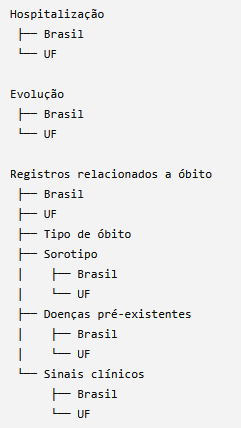

## 15 — Visualizações

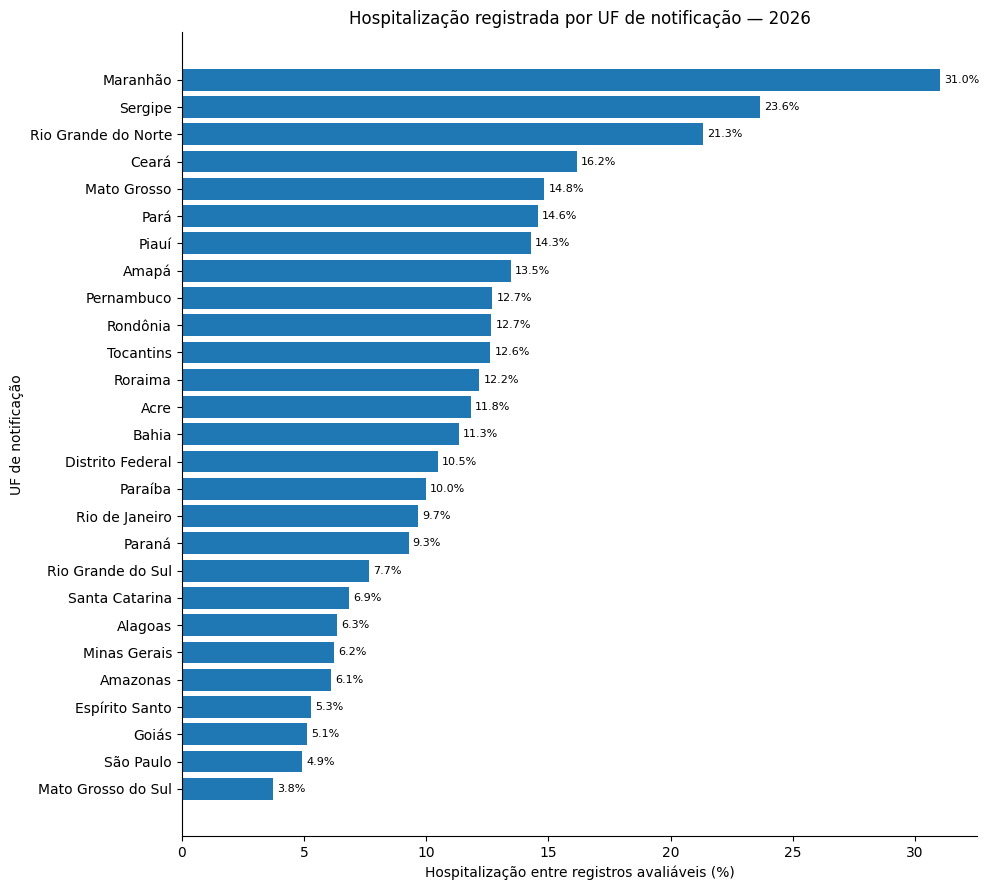

In [75]:
import matplotlib.pyplot as plt

# ============================================================
# HOSPITALIZAÇÃO POR UF
# ============================================================

dados_grafico = (
    hospitalizacao_uf
    .sort_values(
        "PERCENTUAL_HOSPITALIZADOS",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 9)
)

barras = ax.barh(
    dados_grafico["UF_NAME"],
    dados_grafico["PERCENTUAL_HOSPITALIZADOS"]
)

ax.set_title(
    f"Hospitalização registrada por UF de notificação — {ANO}"
)

ax.set_xlabel(
    "Hospitalização entre registros avaliáveis (%)"
)

ax.set_ylabel(
    "UF de notificação"
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in dados_grafico[
            "PERCENTUAL_HOSPITALIZADOS"
        ]
    ],
    padding=3,
    fontsize=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

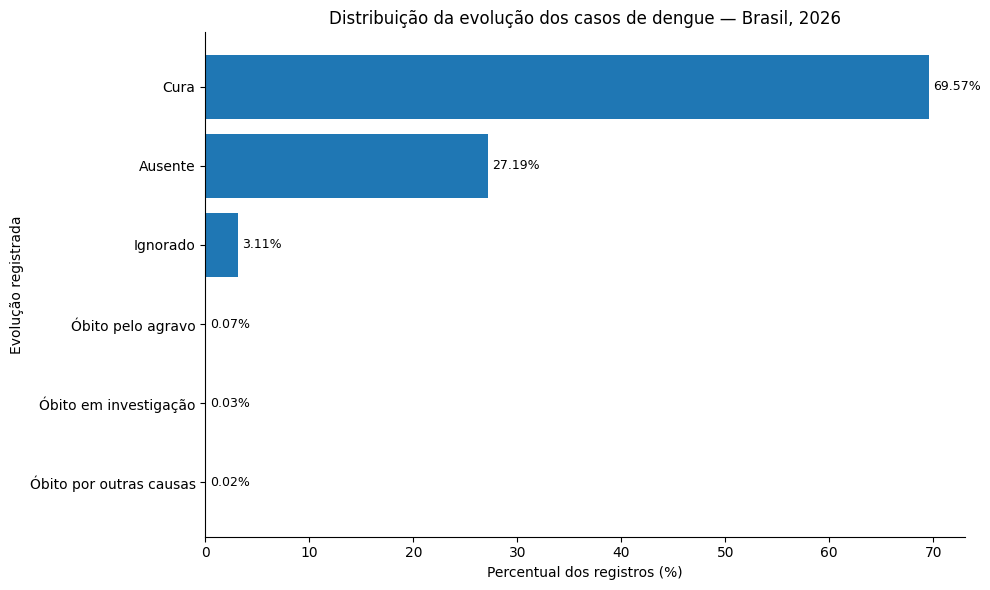

In [76]:
# ============================================================
# DISTRIBUIÇÃO DA EVOLUÇÃO — BRASIL
# ============================================================

dados_grafico = (
    evolucao_brasil
    .sort_values(
        "PERCENTUAL_TOTAL",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

barras = ax.barh(
    dados_grafico["EVOLUCAO"],
    dados_grafico["PERCENTUAL_TOTAL"]
)

ax.set_title(
    f"Distribuição da evolução dos casos de dengue — Brasil, {ANO}"
)

ax.set_xlabel(
    "Percentual dos registros (%)"
)

ax.set_ylabel(
    "Evolução registrada"
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.2f}%"
        for valor in dados_grafico[
            "PERCENTUAL_TOTAL"
        ]
    ],
    padding=3,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

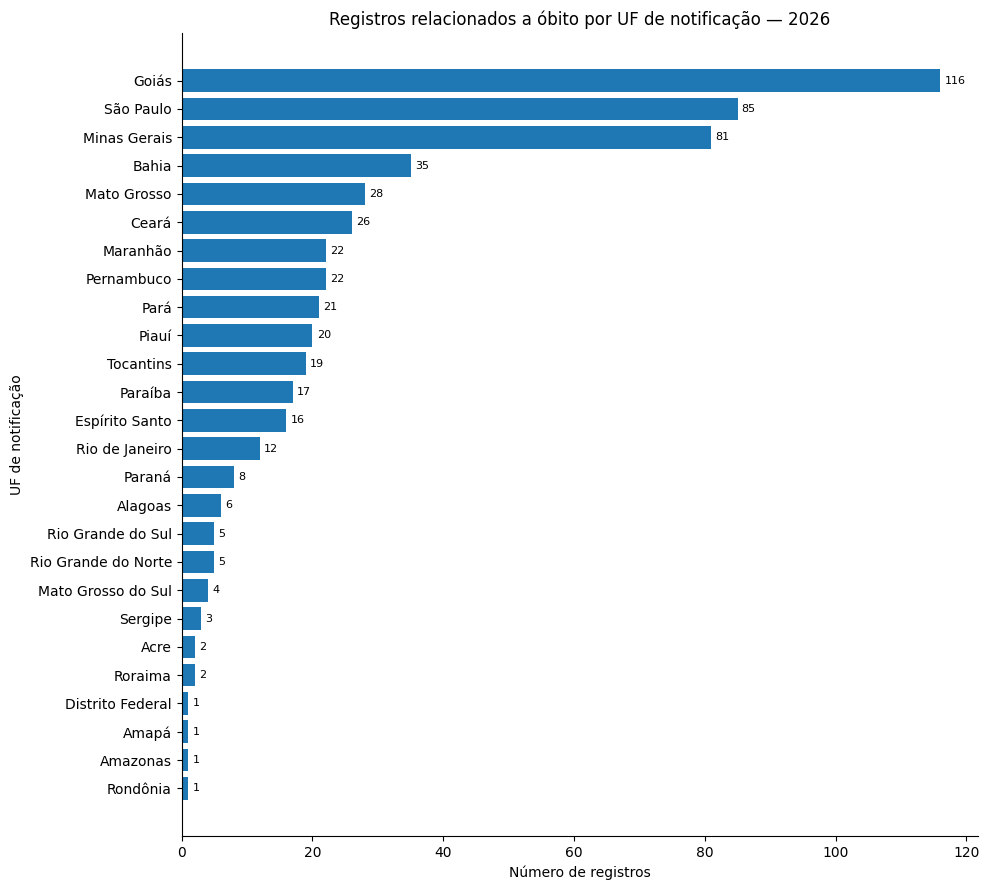

In [77]:
# ============================================================
# REGISTROS RELACIONADOS A ÓBITO POR UF
# ============================================================

dados_grafico = (
    obitos_uf
    .sort_values(
        "TOTAL_REGISTROS_OBITO",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 9)
)

barras = ax.barh(
    dados_grafico["UF_NAME"],
    dados_grafico["TOTAL_REGISTROS_OBITO"]
)

ax.set_title(
    f"Registros relacionados a óbito por UF de notificação — {ANO}"
)

ax.set_xlabel(
    "Número de registros"
)

ax.set_ylabel(
    "UF de notificação"
)

ax.bar_label(
    barras,
    labels=[
        f"{int(valor)}"
        for valor in dados_grafico[
            "TOTAL_REGISTROS_OBITO"
        ]
    ],
    padding=3,
    fontsize=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

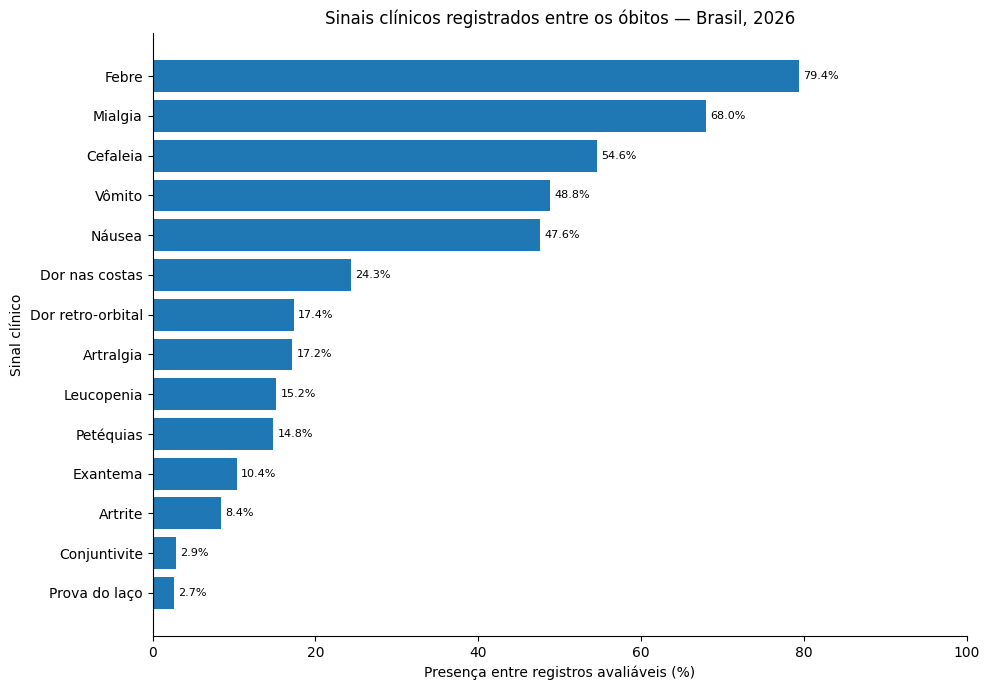

In [78]:
# ============================================================
# SINAIS CLÍNICOS ENTRE OS REGISTROS DE ÓBITO
# ============================================================

dados_grafico = (
    sintomas_obitos_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

barras = ax.barh(
    dados_grafico["SINAL_CLINICO"],
    dados_grafico["PERCENTUAL_SIM"]
)

ax.set_title(
    f"Sinais clínicos registrados entre os óbitos — Brasil, {ANO}"
)

ax.set_xlabel(
    "Presença entre registros avaliáveis (%)"
)

ax.set_ylabel(
    "Sinal clínico"
)

ax.set_xlim(
    0,
    100
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in dados_grafico[
            "PERCENTUAL_SIM"
        ]
    ],
    padding=3,
    fontsize=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

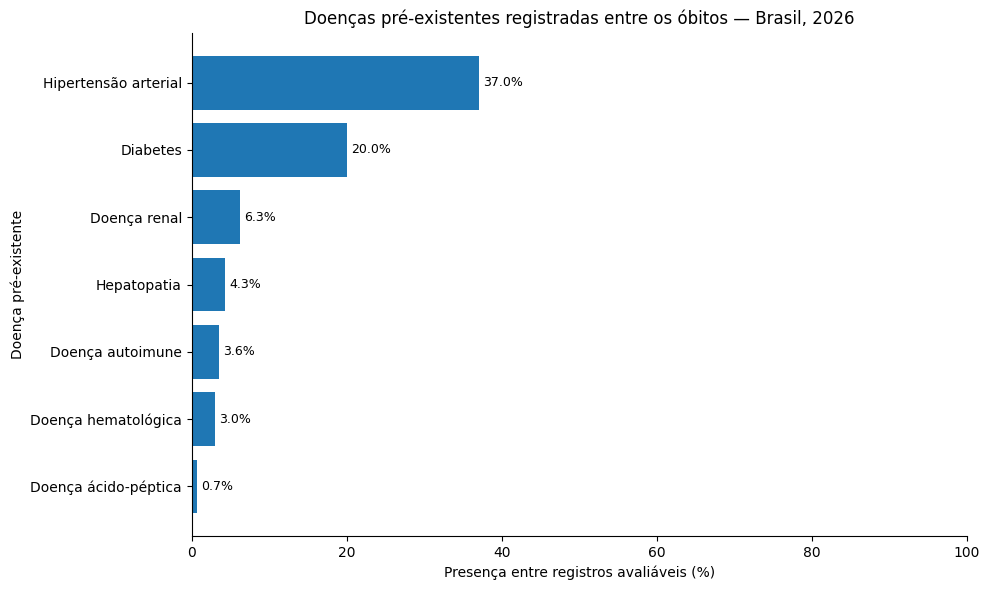

In [79]:
# ============================================================
# DOENÇAS PRÉ-EXISTENTES ENTRE OS REGISTROS DE ÓBITO
# ============================================================

dados_grafico = (
    doencas_preexistentes_obitos_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

barras = ax.barh(
    dados_grafico["DOENCA_PREEXISTENTE"],
    dados_grafico["PERCENTUAL_SIM"]
)

ax.set_title(
    f"Doenças pré-existentes registradas entre os óbitos — Brasil, {ANO}"
)

ax.set_xlabel(
    "Presença entre registros avaliáveis (%)"
)

ax.set_ylabel(
    "Doença pré-existente"
)

ax.set_xlim(
    0,
    100
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in dados_grafico[
            "PERCENTUAL_SIM"
        ]
    ],
    padding=3,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

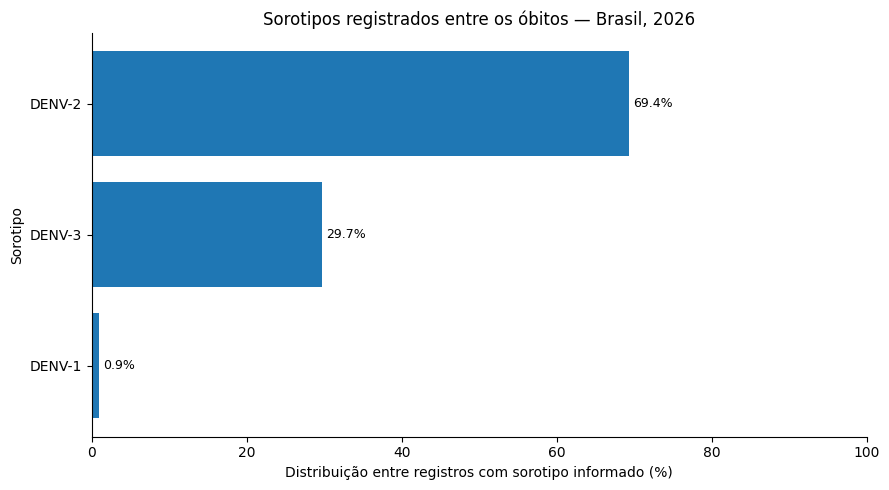

In [80]:
# ============================================================
# SOROTIPOS REGISTRADOS ENTRE OS ÓBITOS
# ============================================================

dados_grafico = (
    obitos_sorotipo_brasil[
        obitos_sorotipo_brasil["SOROTIPO"]
        != "Ausente"
    ]
    .sort_values(
        "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.barh(
    dados_grafico["SOROTIPO"],
    dados_grafico[
        "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
    ]
)

ax.set_title(
    f"Sorotipos registrados entre os óbitos — Brasil, {ANO}"
)

ax.set_xlabel(
    "Distribuição entre registros com sorotipo informado (%)"
)

ax.set_ylabel(
    "Sorotipo"
)

ax.set_xlim(
    0,
    100
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in dados_grafico[
            "PERCENTUAL_ENTRE_SOROTIPOS_INFORMADOS"
        ]
    ],
    padding=3,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Nota de interpretação:** os percentuais apresentados correspondem à
distribuição dos sorotipos entre os registros relacionados a óbito que
possuem informação de sorotipo disponível. Registros sem informação de
sorotipo não integram o denominador. Dessa forma, os resultados devem ser
interpretados considerando a completude dessa variável e não permitem
estabelecer relação causal entre sorotipo e ocorrência de óbito.

## 16. Definir os produtos analíticos finais



In [81]:
# ============================================================
# VERIFICAÇÃO DOS PRODUTOS DE DESFECHO
# ============================================================

produtos_esperados = [
    "hospitalizacao_brasil",
    "hospitalizacao_uf",
    "evolucao_brasil",
    "evolucao_por_uf",
    "obitos_brasil",
    "obitos_tipo_por_uf",
    "obitos_uf",
    "obitos_sorotipo_brasil",
    "obitos_sorotipo_uf",
    "doencas_preexistentes_obitos_brasil",
    "doencas_preexistentes_obitos_uf",
    "sintomas_obitos_brasil",
    "sintomas_obitos_uf"
]

for nome in produtos_esperados:

    existe = nome in globals()

    print(
        f"{nome:<45} "
        f"{'OK' if existe else 'NÃO ENCONTRADO'}"
    )

hospitalizacao_brasil                         OK
hospitalizacao_uf                             OK
evolucao_brasil                               OK
evolucao_por_uf                               OK
obitos_brasil                                 OK
obitos_tipo_por_uf                            OK
obitos_uf                                     OK
obitos_sorotipo_brasil                        OK
obitos_sorotipo_uf                            OK
doencas_preexistentes_obitos_brasil           OK
doencas_preexistentes_obitos_uf               OK
sintomas_obitos_brasil                        OK
sintomas_obitos_uf                            OK


In [82]:
# ============================================================
# PRODUTOS DE DESFECHO FINAIS
# ============================================================

PRODUTOS_DESFECHOS = {

    # --------------------------------------------------------
    # Hospitalização
    # --------------------------------------------------------

    "hospitalizacao_brasil":
        hospitalizacao_brasil,

    "hospitalizacao_uf":
        hospitalizacao_uf,

    # --------------------------------------------------------
    # Evolução
    # --------------------------------------------------------

    "evolucao_brasil":
        evolucao_brasil,

    "evolucao_uf":
        evolucao_por_uf,

    # --------------------------------------------------------
    # Registros relacionados a óbito
    # --------------------------------------------------------

    "obitos_brasil":
        obitos_brasil,

    "obitos_tipo_uf":
        obitos_tipo_por_uf,

    "obitos_uf":
        obitos_uf,

    # --------------------------------------------------------
    # Sorotipos entre os registros de óbito
    # --------------------------------------------------------

    "obitos_sorotipo_brasil":
        obitos_sorotipo_brasil,

    "obitos_sorotipo_uf":
        obitos_sorotipo_uf,

    # --------------------------------------------------------
    # Doenças pré-existentes entre os registros de óbito
    # --------------------------------------------------------

    "doencas_preexistentes_obitos_brasil":
        doencas_preexistentes_obitos_brasil,

    "doencas_preexistentes_obitos_uf":
        doencas_preexistentes_obitos_uf,

    # --------------------------------------------------------
    # Sinais clínicos entre os registros de óbito
    # --------------------------------------------------------

    "sintomas_obitos_brasil":
        sintomas_obitos_brasil,

    "sintomas_obitos_uf":
        sintomas_obitos_uf
}

In [83]:
# ============================================================
# RESUMO DOS PRODUTOS DE DESFECHO
# ============================================================

print(
    f"Quantidade de produtos de desfecho: "
    f"{len(PRODUTOS_DESFECHOS)}"
)

print()

for nome, dataframe in PRODUTOS_DESFECHOS.items():

    print(
        f"{nome:<45} "
        f"{dataframe.shape[0]:>6,} linhas × "
        f"{dataframe.shape[1]:>2} colunas"
    )

Quantidade de produtos de desfecho: 13

hospitalizacao_brasil                              1 linhas × 11 colunas
hospitalizacao_uf                                 27 linhas × 12 colunas
evolucao_brasil                                    6 linhas ×  4 colunas
evolucao_uf                                      142 linhas ×  9 colunas
obitos_brasil                                      3 linhas ×  3 colunas
obitos_tipo_uf                                    61 linhas ×  4 colunas
obitos_uf                                         26 linhas ×  9 colunas
obitos_sorotipo_brasil                             4 linhas ×  4 colunas
obitos_sorotipo_uf                                50 linhas ×  8 colunas
doencas_preexistentes_obitos_brasil                7 linhas ×  9 colunas
doencas_preexistentes_obitos_uf                  182 linhas × 11 colunas
sintomas_obitos_brasil                            14 linhas ×  9 colunas
sintomas_obitos_uf                               364 linhas × 11 colunas


In [84]:
# ============================================================
# VALIDAÇÃO DOS PRODUTOS DE DESFECHO
# ============================================================

problemas = []

for nome, dataframe in PRODUTOS_DESFECHOS.items():

    if not isinstance(
        dataframe,
        pd.DataFrame
    ):
        problemas.append(
            f"{nome}: não é DataFrame"
        )

    elif dataframe.empty:
        problemas.append(
            f"{nome}: DataFrame vazio"
        )


if problemas:

    print(
        "Foram encontrados problemas:"
    )

    for problema in problemas:
        print(
            f"- {problema}"
        )

else:

    print(
        "OK — todos os produtos de desfecho "
        "foram gerados corretamente."
    )

OK — todos os produtos de desfecho foram gerados corretamente.


In [85]:
# ============================================================
# DESCRIÇÃO DOS PRODUTOS DE DESFECHO
# ============================================================

DESCRICAO_PRODUTOS_DESFECHOS = {

    "hospitalizacao_brasil":
        "Resumo nacional da hospitalização dos casos.",

    "hospitalizacao_uf":
        "Hospitalização segundo UF de notificação.",

    "evolucao_brasil":
        "Distribuição nacional da evolução dos casos.",

    "evolucao_uf":
        "Distribuição da evolução segundo UF de notificação.",

    "obitos_brasil":
        "Distribuição nacional dos registros relacionados a óbito.",

    "obitos_tipo_uf":
        "Tipos de óbito registrados segundo UF de notificação.",

    "obitos_uf":
        "Resumo dos registros relacionados a óbito por UF de notificação.",

    "obitos_sorotipo_brasil":
        "Sorotipos registrados entre os registros relacionados a óbito no Brasil.",

    "obitos_sorotipo_uf":
        "Sorotipos registrados entre os registros relacionados a óbito por UF.",

    "doencas_preexistentes_obitos_brasil":
        "Doenças pré-existentes registradas entre os registros relacionados a óbito no Brasil.",

    "doencas_preexistentes_obitos_uf":
        "Doenças pré-existentes registradas entre os registros relacionados a óbito por UF.",

    "sintomas_obitos_brasil":
        "Sinais clínicos registrados entre os registros relacionados a óbito no Brasil.",

    "sintomas_obitos_uf":
        "Sinais clínicos registrados entre os registros relacionados a óbito por UF."
}

## 17. Inventário

In [86]:
# ============================================================
# 17 — INVENTÁRIO DOS PRODUTOS DE DESFECHO
# ============================================================

registros_inventario = []

for nome_produto, dataframe in PRODUTOS_DESFECHOS.items():

    # --------------------------------------------------------
    # Identificação do escopo
    # --------------------------------------------------------

    if nome_produto.endswith("_brasil"):
        escopo = "Brasil"

    elif "_uf" in nome_produto:
        escopo = "UF de notificação"

    else:
        escopo = "Brasil"

    # --------------------------------------------------------
    # Registro do produto
    # --------------------------------------------------------

    registros_inventario.append({

        "PRODUTO":
            nome_produto,

        "DESCRICAO":
            DESCRICAO_PRODUTOS_DESFECHOS.get(
                nome_produto,
                ""
            ),

        "ESCOPO":
            escopo,

        "TOTAL_LINHAS":
            dataframe.shape[0],

        "TOTAL_COLUNAS":
            dataframe.shape[1],

        "COLUNAS":
            ", ".join(
                dataframe.columns.tolist()
            )
    })


inventario_produtos_desfechos = (
    pd.DataFrame(
        registros_inventario
    )
)

In [87]:
display(
    inventario_produtos_desfechos
)

,PRODUTO,DESCRICAO,ESCOPO,TOTAL_LINHAS,TOTAL_COLUNAS,COLUNAS
0,hospitalizacao_brasil,Resumo nacional da hospitalização dos casos.,Brasil,1,11,"ANO, TOTAL_REGISTROS, AVALIAVEIS, HOSPITALIZAD..."
1,hospitalizacao_uf,Hospitalização segundo UF de notificação.,UF de notificação,27,12,"SG_UF_NOT, UF_NAME, TOTAL_REGISTROS, AVALIAVEI..."
2,evolucao_brasil,Distribuição nacional da evolução dos casos.,Brasil,6,4,"EVOLUCAO, TOTAL_REGISTROS, PERCENTUAL_TOTAL, P..."
3,evolucao_uf,Distribuição da evolução segundo UF de notific...,UF de notificação,142,9,"SG_UF_NOT, UF_NAME, EVOLUCAO_DECODED, TOTAL_RE..."
4,obitos_brasil,Distribuição nacional dos registros relacionad...,Brasil,3,3,"EVOLUCAO_DECODED, TOTAL_OBITOS, PERCENTUAL_ENT..."
5,obitos_tipo_uf,Tipos de óbito registrados segundo UF de notif...,UF de notificação,61,4,"SG_UF_NOT, UF_NAME, EVOLUCAO_DECODED, TOTAL_OB..."
6,obitos_uf,Resumo dos registros relacionados a óbito por ...,UF de notificação,26,9,"SG_UF_NOT, UF_NAME, TOTAL_REGISTROS_OBITO, TOT..."
7,obitos_sorotipo_brasil,Sorotipos registrados entre os registros relac...,Brasil,4,4,"SOROTIPO, TOTAL_REGISTROS_OBITO, PERCENTUAL_TO..."
8,obitos_sorotipo_uf,Sorotipos registrados entre os registros relac...,UF de notificação,50,8,"SG_UF_NOT, UF_NAME, SOROTIPO_DECODED, TOTAL_RE..."
9,doencas_preexistentes_obitos_brasil,Doenças pré-existentes registradas entre os re...,Brasil,7,9,"VARIAVEL, DOENCA_PREEXISTENTE, TOTAL_REGISTROS..."


In [88]:
inventario_produtos_desfechos = (
    inventario_produtos_desfechos
    .sort_values(
        "PRODUTO"
    )
    .reset_index(
        drop=True
    )
)

display(
    inventario_produtos_desfechos
)

,PRODUTO,DESCRICAO,ESCOPO,TOTAL_LINHAS,TOTAL_COLUNAS,COLUNAS
0,doencas_preexistentes_obitos_brasil,Doenças pré-existentes registradas entre os re...,Brasil,7,9,"VARIAVEL, DOENCA_PREEXISTENTE, TOTAL_REGISTROS..."
1,doencas_preexistentes_obitos_uf,Doenças pré-existentes registradas entre os re...,UF de notificação,182,11,"SG_UF_NOT, UF_NAME, VARIAVEL, DOENCA_PREEXISTE..."
2,evolucao_brasil,Distribuição nacional da evolução dos casos.,Brasil,6,4,"EVOLUCAO, TOTAL_REGISTROS, PERCENTUAL_TOTAL, P..."
3,evolucao_uf,Distribuição da evolução segundo UF de notific...,UF de notificação,142,9,"SG_UF_NOT, UF_NAME, EVOLUCAO_DECODED, TOTAL_RE..."
4,hospitalizacao_brasil,Resumo nacional da hospitalização dos casos.,Brasil,1,11,"ANO, TOTAL_REGISTROS, AVALIAVEIS, HOSPITALIZAD..."
5,hospitalizacao_uf,Hospitalização segundo UF de notificação.,UF de notificação,27,12,"SG_UF_NOT, UF_NAME, TOTAL_REGISTROS, AVALIAVEI..."
6,obitos_brasil,Distribuição nacional dos registros relacionad...,Brasil,3,3,"EVOLUCAO_DECODED, TOTAL_OBITOS, PERCENTUAL_ENT..."
7,obitos_sorotipo_brasil,Sorotipos registrados entre os registros relac...,Brasil,4,4,"SOROTIPO, TOTAL_REGISTROS_OBITO, PERCENTUAL_TO..."
8,obitos_sorotipo_uf,Sorotipos registrados entre os registros relac...,UF de notificação,50,8,"SG_UF_NOT, UF_NAME, SOROTIPO_DECODED, TOTAL_RE..."
9,obitos_tipo_uf,Tipos de óbito registrados segundo UF de notif...,UF de notificação,61,4,"SG_UF_NOT, UF_NAME, EVOLUCAO_DECODED, TOTAL_OB..."


In [89]:
# ============================================================
# VALIDAÇÃO DO INVENTÁRIO
# ============================================================

print(
    f"Produtos em PRODUTOS_DESFECHOS: "
    f"{len(PRODUTOS_DESFECHOS)}"
)

print(
    f"Produtos no inventário: "
    f"{len(inventario_produtos_desfechos)}"
)

assert (
    len(inventario_produtos_desfechos)
    ==
    len(PRODUTOS_DESFECHOS)
), (
    "O inventário não possui a mesma quantidade "
    "de produtos de PRODUTOS_DESFECHOS."
)

print(
    "OK — inventário dos produtos de desfecho validado."
)

Produtos em PRODUTOS_DESFECHOS: 13
Produtos no inventário: 13
OK — inventário dos produtos de desfecho validado.


In [90]:
produtos_dicionario = set(
    PRODUTOS_DESFECHOS.keys()
)

produtos_inventario = set(
    inventario_produtos_desfechos[
        "PRODUTO"
    ]
)

assert (
    produtos_dicionario
    ==
    produtos_inventario
), (
    "Existem diferenças entre os produtos "
    "do dicionário e do inventário."
)

print(
    "OK — todos os produtos estão documentados "
    "no inventário."
)

OK — todos os produtos estão documentados no inventário.


## 18 — Salvamento dos produtos de desfecho.

In [91]:
## ============================================================
# SALVAMENTO DOS PRODUTOS ANALÍTICOS
# ============================================================

arquivos_salvos = []

for nome_produto, dataframe in PRODUTOS_DESFECHOS.items():

    caminho_arquivo = (
        PASTA_SAIDA
        / f"{nome_produto}.parquet"
    )

    dataframe.to_parquet(
        caminho_arquivo,
        index=False
    )

    arquivos_salvos.append(
        {
            "PRODUTO": nome_produto,
            "ARQUIVO": caminho_arquivo.name,
            "CAMINHO": str(caminho_arquivo),
            "TOTAL_LINHAS": len(dataframe),
            "TOTAL_COLUNAS": dataframe.shape[1]
        }
    )

    print(
        f"OK — {nome_produto} "
        f"({len(dataframe):,} linhas)"
    )

OK — hospitalizacao_brasil (1 linhas)
OK — hospitalizacao_uf (27 linhas)
OK — evolucao_brasil (6 linhas)
OK — evolucao_uf (142 linhas)
OK — obitos_brasil (3 linhas)
OK — obitos_tipo_uf (61 linhas)
OK — obitos_uf (26 linhas)
OK — obitos_sorotipo_brasil (4 linhas)
OK — obitos_sorotipo_uf (50 linhas)
OK — doencas_preexistentes_obitos_brasil (7 linhas)
OK — doencas_preexistentes_obitos_uf (182 linhas)
OK — sintomas_obitos_brasil (14 linhas)
OK — sintomas_obitos_uf (364 linhas)


In [92]:
# ============================================================
# SALVAMENTO DO INVENTÁRIO
# ============================================================

caminho_inventario = (
    PASTA_SAIDA
    / "inventario_produtos_desfechos.csv"
)

inventario_produtos_desfechos.to_csv(
    caminho_inventario,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Inventário salvo em:\n"
    f"{caminho_inventario}"
)

Inventário salvo em:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/desfechos/inventario_produtos_desfechos.csv


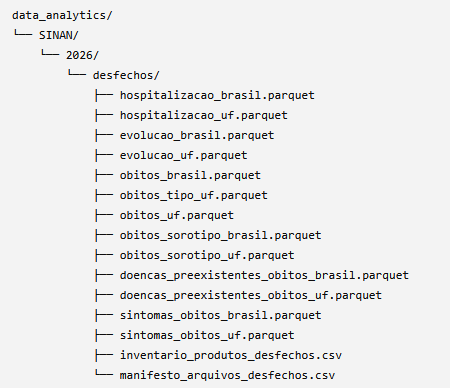

O arquivo manifesto_arquivos_defechos.csv não é necessário e não será gerado